<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 8 (effective batch size ≈ 128, tuned value = 128)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 8 micro-batches per optimizer step (effective batch size ≈ micro_batch x 8).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.65e-05 | train loss 1.2496 acc 0.582 | val loss 0.9749 acc 0.705 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.65e-05 | train loss 0.7710 acc 0.710 | val loss 0.6218 acc 0.794 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.65e-05 | train loss 0.5361 acc 0.765 | val loss 0.4735 acc 0.830 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.65e-05 | train loss 0.4270 acc 0.818 | val loss 0.4235 acc 0.861 *


...

[ConvNeXt-Tiny] Epoch  16/100 | LR: 5.65e-05 | train loss 0.0963 acc 0.951 | val loss 0.3995 acc 0.887


[ConvNeXt-Tiny] Epoch  17/100 | LR: 5.65e-05 | train loss 0.0746 acc 0.969 | val loss 0.4412 acc 0.889


[ConvNeXt-Tiny] Epoch  18/100 | LR: 5.65e-05 | train loss 0.0753 acc 0.960 | val loss 0.4018 acc 0.877


[ConvNeXt-Tiny] Epoch  19/100 | LR: 5.65e-05 | train loss 0.0640 acc 0.970 | val loss 0.3942 acc 0.895


[ConvNeXt-Tiny] Epoch  20/100 | LR: 5.65e-05 | train loss 0.0556 acc 0.978 | val loss 0.4172 acc 0.885

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 20.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3300)


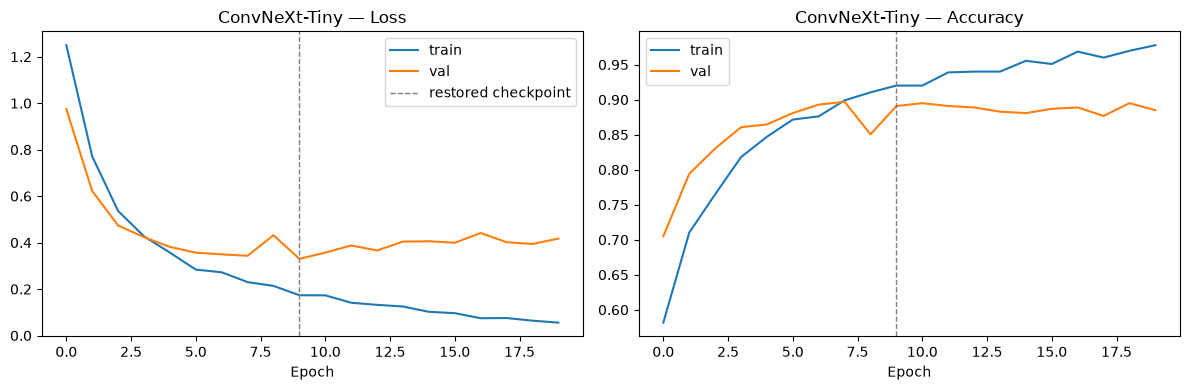

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.889


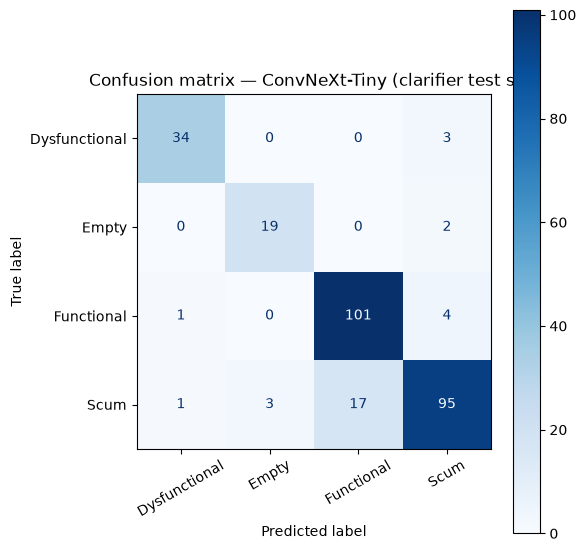

               precision    recall  f1-score   support

Dysfunctional      0.944     0.919     0.932        37
        Empty      0.864     0.905     0.884        21
   Functional      0.856     0.953     0.902       106
         Scum      0.913     0.819     0.864       116

     accuracy                          0.889       280
    macro avg      0.894     0.899     0.895       280
 weighted avg      0.892     0.889     0.889       280



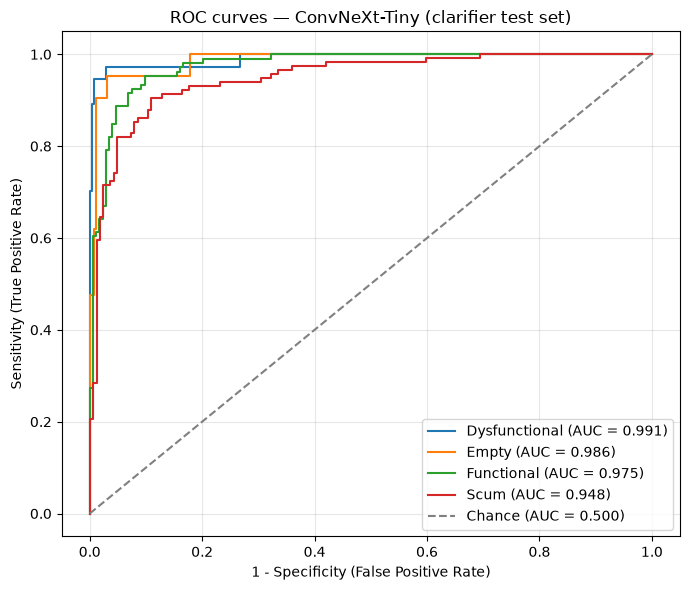

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.991
  Empty          : 0.986
  Functional     : 0.975
  Scum           : 0.948

Mean AUC (over 4/4 classes with test examples): 0.975


(np.float64(0.8892857142857142),
 {'Dysfunctional': 0.9907685463241018,
  'Empty': 0.9856591285162715,
  'Functional': 0.9746258945998698,
  'Scum': 0.9480130361648444})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/clarifier_aug/results_clarifier_convnext_tiny_stratified.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
